<img src="./logo_UTN.svg" align="right" width="150" /> 

#### Análisis y Procesamiento de Señales

# Trabajo Práctico Nº1
#### Nicolas Bravo

# Introduccion

En este trabajo se va a generar una señal senoidal y una señal rectangular, la primera con una potencia media de 2W y la segunda con una potencia de 1W, y posteriormente calcular y graficar su fft.

Tambien se van a generar dos secuencias aleatorias de ruido (una con una distribucion normal y otra con una distribucion uniforme).

### Codigo a utilizar:

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy as scp
#%%
N = 1000 #[muestras]  Cant de muestras
fs = 20000 #[Hz]       Frecuencia de muestras // Variar
pot_in = 2              #[W] Potencia de la señal
vmax = 1        #[volts]
dc = 0      #[volts]
ff = 2000       #[Hz] "ciclos que entran en la muestra
ph = 0      #[rad]
ph2 = np.pi/2
nn = N      #[muestras]
fs = fs         #[Hz]
pot_r = 0.1
#%%

def mi_funcion_sen (vmax, dc, ff, ph, nn, fs):
    
    tt = np.arange(start=0, stop=nn/fs, step=1/fs)
    xx = vmax*np.sin(2*np.pi * ff * tt + ph) + dc
    
    return (tt, xx)

def mi_funcion_rect (vmax = 1, dc = 0, ff = 1, ph = 0, nn = N, fs = fs):
    
    tt = np.arange(start=0, stop=nn/fs, step=1/fs)
    xx = vmax * scp.signal.square(2 * np.pi * ff * tt) + dc
    
    return (tt, xx)
    
def calculo_c_pot (pot = 1):
    vmax = np.sqrt(pot*2)
    return (vmax)

def calculo_limites_unif (var):
    limite = np.sqrt(12*var/4)
    return(limite)

angulo en 2000Hz es de [-1.57079633]


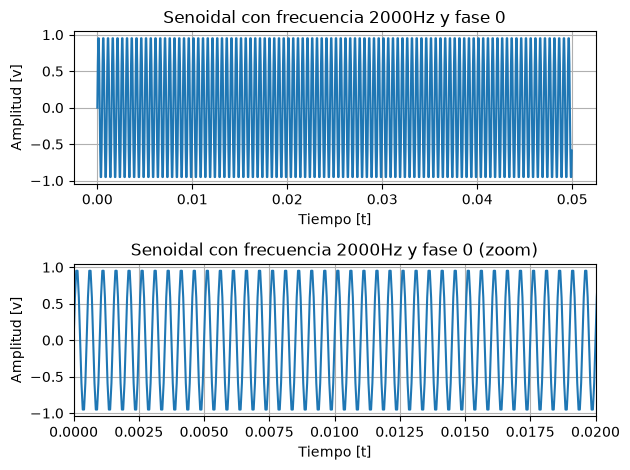

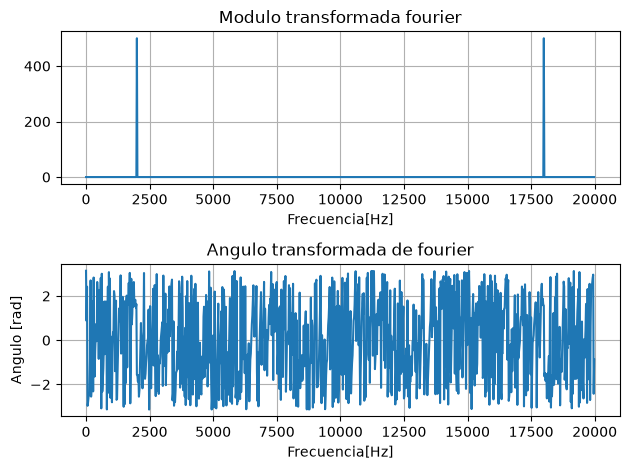

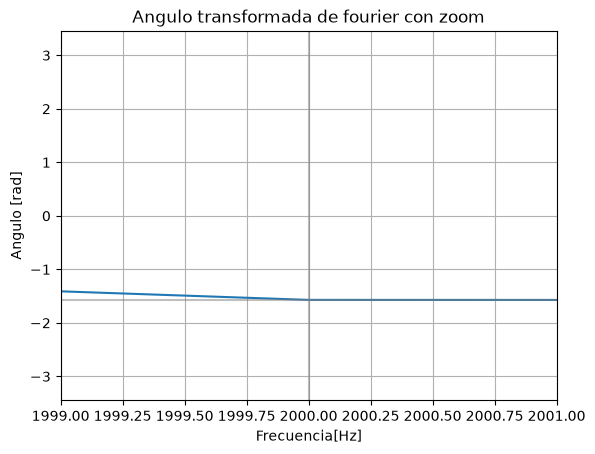

In [2]:
#%% Seno phase 0

plt.close("all")

tt, xx = mi_funcion_sen(vmax, dc, ff, ph, nn, fs)

frec = np.arange(start=0,step=fs,stop=fs*N)/N
xxf = np.abs(np.fft.fft(xx))
angx = np.angle(np.fft.fft(xx))

plt.subplot(2,1,1)
plt.plot(tt, xx)
plt.title(f"Senoidal con frecuencia {ff}Hz y fase 0")
plt.xlabel("Tiempo [t]")
plt.ylabel("Amplitud [v]")
plt.grid()

plt.subplot(2,1,2)
plt.plot(tt, xx)
plt.title(f"Senoidal con frecuencia {ff}Hz y fase 0 (zoom)")
plt.xlabel("Tiempo [t]")
plt.ylabel("Amplitud [v]")
plt.xlim(0,0.02)
plt.grid()
plt.tight_layout()
plt.figure()

plt.subplot(2,1,1)
plt.plot(frec, xxf)
plt.title("Modulo transformada fourier")
plt.xlabel("Frecuencia[Hz]")
plt.grid()

plt.subplot(2,1,2)
plt.plot(frec, angx)
plt.grid()
plt.title("Angulo transformada de fourier")
plt.xlabel("Frecuencia[Hz]")
plt.ylabel("Angulo [rad]")
plt.tight_layout()

plt.figure()
plt.plot(frec, angx)
plt.xlim(1999,2001)
plt.axvline(x = 2000, color='gray', alpha = 0.5)
plt.axhline(y = -np.pi/2, color='gray', alpha = 0.5)
plt.title("Angulo transformada de fourier con zoom")
plt.xlabel("Frecuencia[Hz]")
plt.ylabel("Angulo [rad]")
plt.grid()

print(f"angulo en {ff}Hz es de {angx[frec == ff]}")

Se puede apreciar que los picos en el grafico del modulo de la fft se generan en 2000Hz y 18000Hz dado a una simetria en la frecuencia de Nyquist y al medir el angulo que se genera a los 2000Hz, este es aproximadamente $-1.57\ o\  -\pi/2$ y no la fase que se le dio de 0. Esto se debe a que la fase de la FFT se interpreta naturalmente con el coseno como referencia (al ser la parte real de una exponencial compleja) y el este mismo se encuentra desfasado $90° o\   \pi/2$ del seno.

angulo en 2000Hz es de [-1.04587497e-14]
Potencia calculada con parseal = 2.0


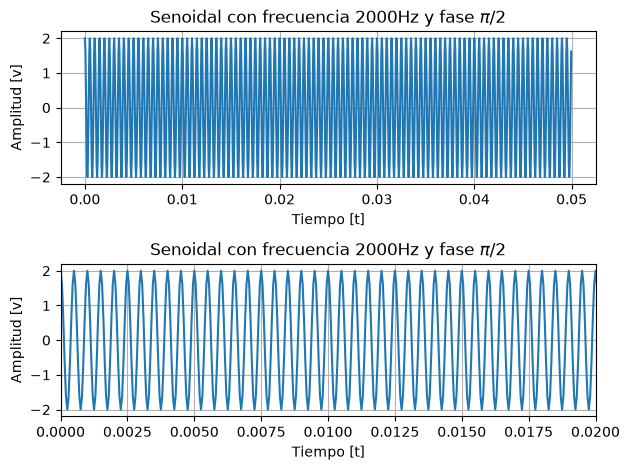

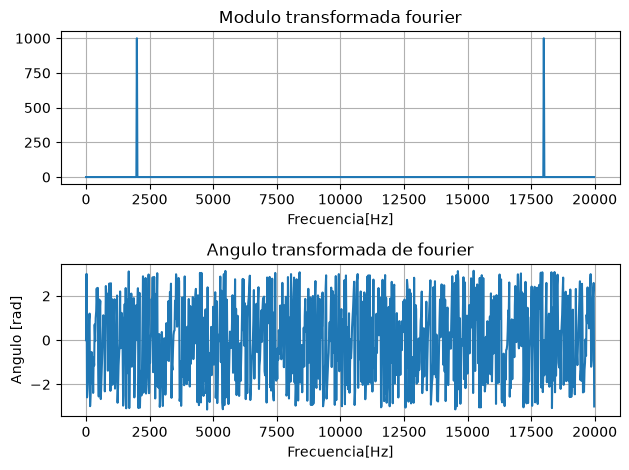

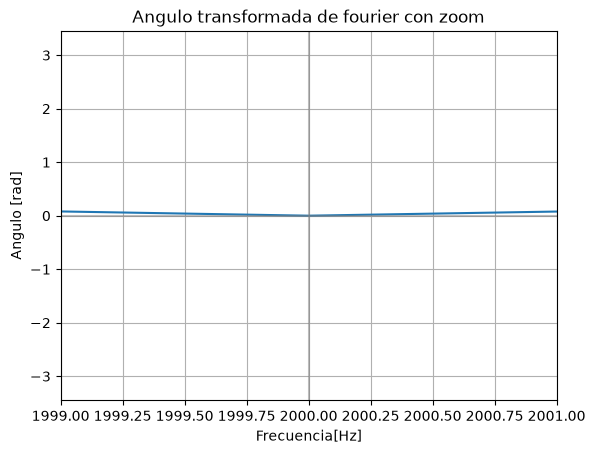

In [3]:
#%% Seno phase pi/2
vmax2 = calculo_c_pot(pot_in)
tt2, xx2 = mi_funcion_sen(vmax2, dc, ff, ph2, nn, fs)
frec2 = np.arange(start=0,step=fs,stop=fs*N)/N
xxf2 = np.abs(np.fft.fft(xx2))
angx2 = np.angle(np.fft.fft(xx2))

plt.subplot(2,1,1)
plt.plot(tt2, xx2)
plt.title(f"Senoidal con frecuencia {ff}Hz y fase $\pi/2$")
plt.xlabel("Tiempo [t]")
plt.ylabel("Amplitud [v]")
plt.grid()

plt.subplot(2,1,2)
plt.plot(tt2, xx2)
plt.title(f"Senoidal con frecuencia {ff}Hz y fase $\pi/2$")
plt.xlabel("Tiempo [t]")
plt.ylabel("Amplitud [v]")
plt.xlim(0,0.02)
plt.grid()
plt.tight_layout()

plt.figure()
plt.subplot(2,1,1)
plt.plot(frec2, xxf2)
plt.title("Modulo transformada fourier")
plt.xlabel("Frecuencia[Hz]")
plt.grid()

plt.subplot(2,1,2)
plt.plot(frec2, angx2)
plt.title("Angulo transformada de fourier")
plt.xlabel("Frecuencia[Hz]")
plt.ylabel("Angulo [rad]")
plt.grid()
plt.tight_layout()

plt.figure()
plt.plot(frec2, angx2)
plt.xlim(1999,2001)
plt.axvline(x = 2000, color='gray', alpha = 0.5)
plt.axhline(y = 0, color='gray', alpha = 0.5)
plt.title("Angulo transformada de fourier con zoom")
plt.xlabel("Frecuencia[Hz]")
plt.ylabel("Angulo [rad]")
plt.grid()

pot_pars = 1/(N**2)*sum(xxf2**2)
print(f"angulo en {ff}Hz es de {angx2[frec == ff]}")
print(f"Potencia calculada con parseal = {pot_pars}")

Se Puede ver que los picos del modulo de la FFT no varian con el cambio de fase, al medir el angulo en la frecuencia de la señal, este es de aproximadamente 0 lo cual se explica con lo mencionado anteriormente.
Para poder calcular la potencia de una señal solo con su FFT se utiliza el teorema de Parseval $P = \frac{1}{N^2} \sum_{n=0}^{N-1} |X[n]|^2$ el cual relaciona la potencia de una señal con la potencia de su transformada de Fourier.

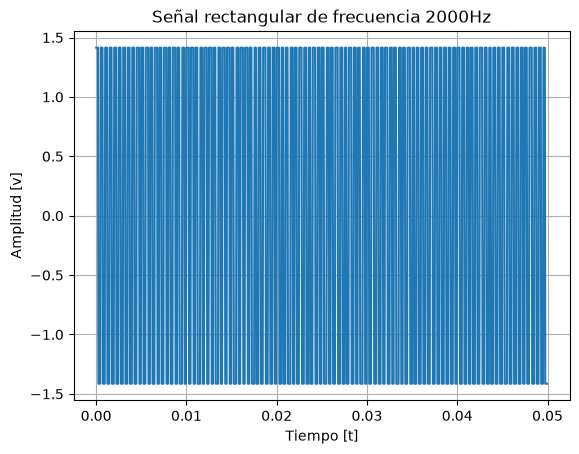

In [4]:
#%% Pulso rectangular
vmax = calculo_c_pot(pot = 1)
ttc, xxc = mi_funcion_rect(ff = ff, vmax = vmax)
fftc = np.abs(np.fft.fft(xxc))
frec_c = np.arange(start=0,step=fs,stop=fs*N)/N
plt.figure()
plt.plot(ttc, xxc)
plt.title(f"Señal rectangular de frecuencia {ff}Hz")
plt.xlabel("Tiempo [t]")
plt.ylabel("Amplitud [v]")
plt.grid()

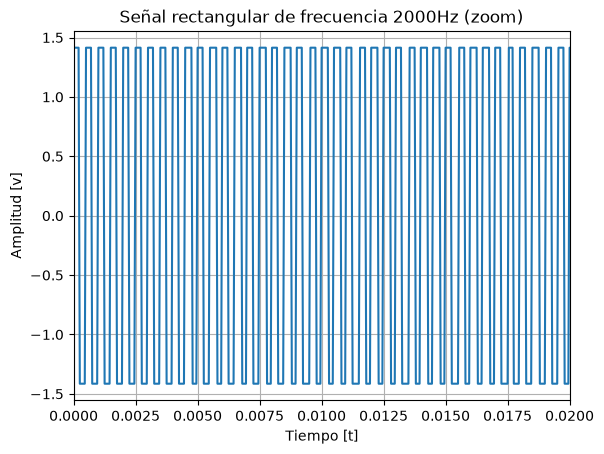

In [5]:
plt.figure()
plt.plot(ttc, xxc)
plt.title(f"Señal rectangular de frecuencia {ff}Hz (zoom)")
plt.xlabel("Tiempo [t]")
plt.ylabel("Amplitud [v]")
plt.xlim(0,0.02)
plt.grid()

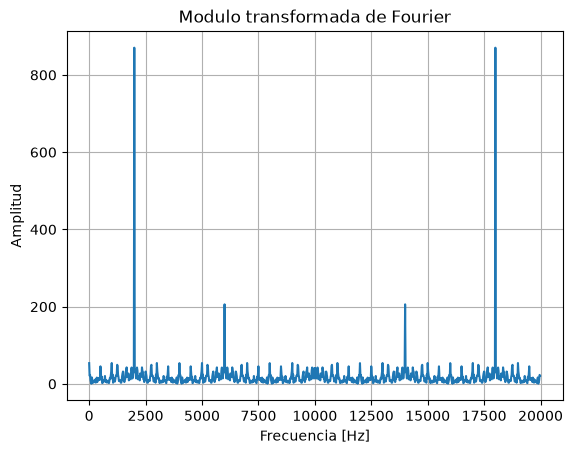

In [6]:
plt.figure()
plt.plot(frec_c, fftc)
plt.title("Modulo transformada de Fourier")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Amplitud")
plt.grid()

En el grafico del modulo de la FFT de la señal rectangular se puede ver el pico principal en la frecuencia de la señal y se pueden apreciar varios picos menores, esto es porque la señal cuadrada esta compuesta por muchas componentes sinusoidales y, por lo tanto, de diferentes frecuencias. Hay un pico menor en la frecuencia de 6000Hz, esto corresponde al primer armonico impar, estos permiten construir la forma cuadrada de la señal partiendo de su serie de Fourier

### Extra
A continuacion se realiza la simulación en python de los ejercicios en lapiz y papel de la practica.

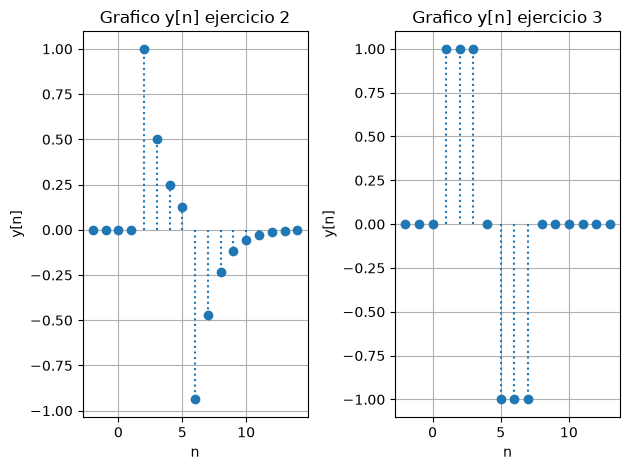

In [7]:
import numpy as np
import matplotlib.pyplot as plt

#%% Ejercicio 2
n3 = np.arange(-2, 15, step = 1)
x3 = np.where(n3 >= 0, 1, 0)
x4 = (1/2)**n3
x5 = x3 * x4
h2 = np.zeros_like(n3, dtype=float)
h2[n3 == 0] = 1
h2[n3 == 4] = -1
y2 = np.convolve(x5, h2)
y2 = y2[:len(y2) - len(n3)+1]
n4 = np.arange(2*n3[0], 2*n3[0] + len(y2))
plt.subplot(1,2,1)
plt.stem(n3, y2, ':', basefmt=' ')
plt.title('Grafico y[n] ejercicio 2')
plt.xlabel('n')
plt.ylabel('y[n]')
plt.grid()
#%% Ejercicio 3
n = np.arange(-2, 14, step = 1)
x1 = np.where(n >= -1, 1, 0)
x2 = np.where(n >= 2, 1, 0)
x = x1 - x2
h = np.zeros_like(n, dtype=float)
h[n == 0] = 1
h[n == 4] = -1
y = np.convolve(x, h)
y = y[:len(y) - len(n)+1]
n2 = np.arange(2*n[0], 2*n[0] + len(y))
plt.subplot(1,2,2)
plt.stem(n, y, ':', basefmt=' ')
plt.title('Grafico y[n] ejercicio 3')
plt.xlabel('n')
plt.ylabel('y[n]')
plt.grid()
plt.tight_layout()